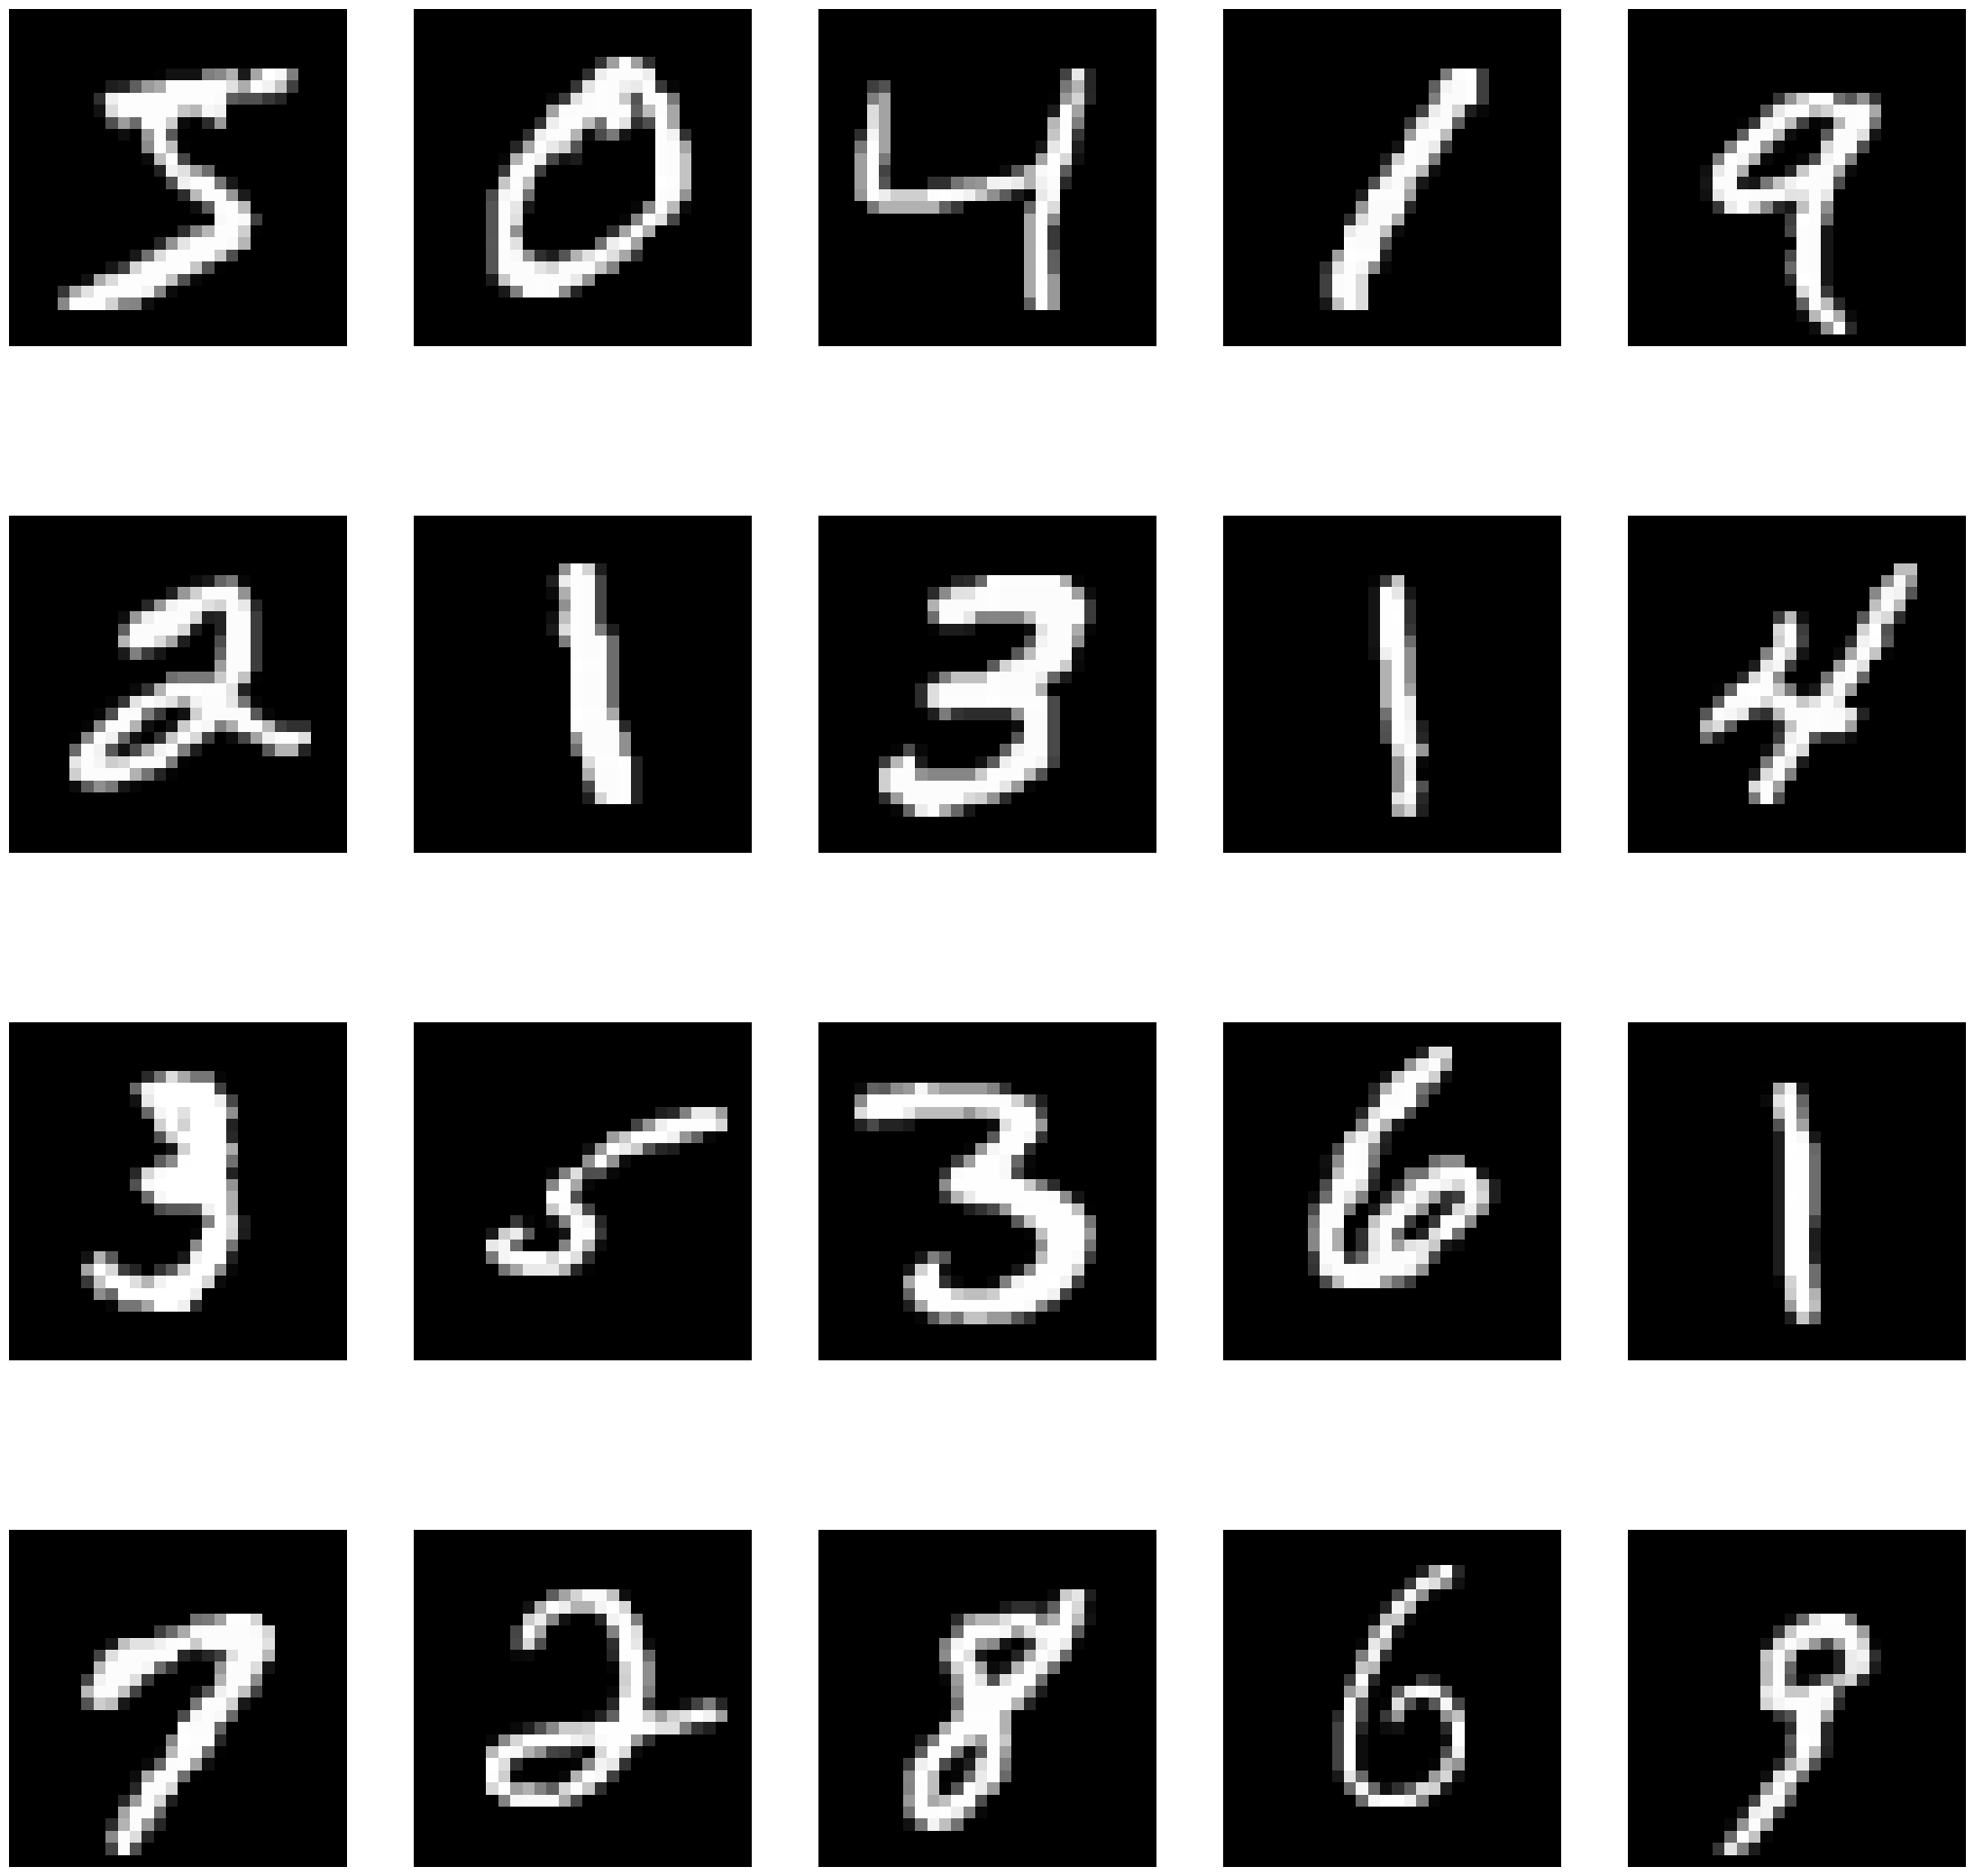

In [1]:
import pickle
import sys, os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.pardir)
#導入父目錄的文件


(x_train, t_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path= 'mnist.npz')

plt.figure(figsize=(28,28))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap= "gray")
    plt.axis('off')

plt.show()


In [2]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image


def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)  # 5

print(img.shape)  # (784,)
img = img.reshape(28, 28)  # 形状を元の画像サイズに変形
print(img.shape)  # (28, 28)

img_show(img)


5
(784,)
(28, 28)


In [3]:
import sys,os
sys.path.append(os.pardir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [4]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax

def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True,one_hot_label=False)
    return x_test,t_test

def init_network():
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)

    return network

def predict(network, x):
    W1,W2,W3 = network['W1'], network['W2'], network['W3']
    b1,b2,b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

x,t = get_data()
network = init_network()

accuracy_cnt = 0
for i in range(len(x)):
        y = predict(network, x[i])
        p = np.argmax(y)
        if p == t[i]:
            accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))



Accuracy:0.9352


In [5]:
x,_ =get_data()
network = init_network()
W1,W2,W3 = network['W1'],network['W2'],network['W3']

x.shape

(10000, 784)

In [6]:
x[0].shape

(784,)

In [7]:
W1.shape

(784, 50)

In [8]:
W2.shape

(50, 100)

In [9]:
W3.shape

(100, 10)

In [10]:
x, t = get_data()
network = init_network()

batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

    print("Accuracy:" +str(float(accuracy_cnt) / len(x)))

Accuracy:0.0096
Accuracy:0.0194
Accuracy:0.0287
Accuracy:0.0377
Accuracy:0.0471
Accuracy:0.056
Accuracy:0.0653
Accuracy:0.0748
Accuracy:0.0841
Accuracy:0.0932
Accuracy:0.1024
Accuracy:0.1114
Accuracy:0.1201
Accuracy:0.1293
Accuracy:0.1383
Accuracy:0.1473
Accuracy:0.1564
Accuracy:0.1651
Accuracy:0.1743
Accuracy:0.1831
Accuracy:0.1921
Accuracy:0.2009
Accuracy:0.2105
Accuracy:0.2197
Accuracy:0.2289
Accuracy:0.2379
Accuracy:0.2473
Accuracy:0.2567
Accuracy:0.2662
Accuracy:0.2753
Accuracy:0.285
Accuracy:0.2939
Accuracy:0.3034
Accuracy:0.3131
Accuracy:0.3223
Accuracy:0.3314
Accuracy:0.3408
Accuracy:0.3496
Accuracy:0.3577
Accuracy:0.3667
Accuracy:0.3759
Accuracy:0.3851
Accuracy:0.3941
Accuracy:0.403
Accuracy:0.412
Accuracy:0.4214
Accuracy:0.4311
Accuracy:0.4405
Accuracy:0.4493
Accuracy:0.4587
Accuracy:0.468
Accuracy:0.4777
Accuracy:0.4875
Accuracy:0.4974
Accuracy:0.5072
Accuracy:0.5172
Accuracy:0.5264
Accuracy:0.5361
Accuracy:0.5454
Accuracy:0.5544
Accuracy:0.5636
Accuracy:0.573
Accuracy:0.583

In [11]:
list(range(0,10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
list(range(0, 10, 3))

[0, 3, 6, 9]

In [13]:
x = np.array([[0.1, 0.8, 0.1], [0.3, 0.1, 0.6],
             [0.2, 0.5, 0.3],[0.8, 0.1, 0.1]])
y = np.argmax(x, axis=1)
print(y)

[1 2 1 0]


In [14]:
y = np.array([1, 2, 1, 0])
t = np.array([1, 2 ,0, 0])
print(y == t)
np.sum(y == t)

[ True  True False  True]


np.int64(3)

In [15]:
def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t) **2)

t = [0,0,1,0,0,0,0,0,0,0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
mean_squared_error(np.array(y), np.array(t))

np.float64(0.09750000000000003)

y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
mean_squared_error(np.array(y), np.array(t))

In [16]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
mean_squared_error(np.array(y), np.array(t))

np.float64(0.5975)

In [17]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [18]:
t = [0,0,1,0,0,0,0,0,0,0]
y = [0.1, 0.05, 0.6, 00, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
cross_entropy_error(np.array(y), np.array(t))

np.float64(0.510825457099338)

In [19]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
cross_entropy_error(np.array(y), np.array(t))

np.float64(2.302584092994546)

In [20]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train,t_train), (x_test ,t_test) = load_mnist(normalize=True, one_hot_label= True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [21]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
np.random.choice(60000, 10)

array([49556,  7479, 45166, 57677, 10586, 53888, 19625, 50864,  4286,
       52406], dtype=int32)

In [22]:
def cross_entropy_error(y,t):
    if y.ndim == 1:
        t= t.reshape(1, t.size)
        y= y.reshape(1, y.size)

        batch_size = y.shape[0]
        return -np.sum(t * np.log(y + 1e-7)) / batch_size

In [23]:
def numerical_diff(f,x):
    h = 1e-4
    return (f(x+h)-f(x-h)) / (2 * h)

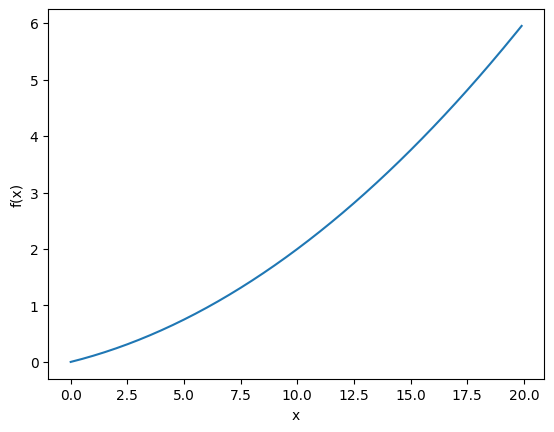

In [24]:
def function_1(x):
    return  0.01*x**2+ 0.1 * x

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [25]:
numerical_diff(function_1, 5)

0.1999999999990898

In [26]:
numerical_diff(function_1,10)

0.2999999999986347

In [27]:
def function_2(x):
    return x[0]**2 + x[1]**2

In [28]:
def function_tmp1(x0):
    return x0*x0 + 4.0**2.0

numerical_diff(function_tmp1, 3.0)

6.00000000000378

In [29]:
def function_tmp2(x1):
    return 3.0**2.0 + x1*x1

numerical_diff(function_tmp2, 4.0)

7.999999999999119

In [30]:
def numerical_gradient(f,x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]
        #calculation of f(x+h)
        x[idx] = tmp_val + h
        fxh1 = f(x)

        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val

    return grad

numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [31]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [32]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

In [33]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f,x)
        x -= lr * grad

        return x

In [34]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])

In [137]:
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-3.12888726e-10,  4.17184968e-10])

In [140]:
init_x=np.array([-3.0,4.0])

array([ 57., -76.])

In [149]:
gradient_descent(function_2, init_x=init_x, lr=10.0, step_num=100)

array([-2.58983747e+13, -1.29524862e+12])

In [150]:
init_x = np.array([-3.0, 4.0])

In [153]:
gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100)

array([-3.,  4.])

In [2]:
import sys,os
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y,t)

        return loss

In [3]:
net = simpleNet()
print(net.W)

[[-1.27630955 -0.12826562 -0.48893185]
 [-0.92114875  0.46616964  0.9755147 ]]


In [4]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[-1.5948196   0.3425933   0.58460412]


In [5]:
np.argmax(p)

np.int64(2)

In [6]:
t = np.array([0, 0, 1])
net.loss(x,t)

np.float64(0.6408818447114525)

In [7]:
def f(W):
    return net.loss(x,t)

dW = numerical_gradient(f,net.W)
print(dW)

[[ 0.03575263  0.2481508  -0.28390342]
 [ 0.05362894  0.3722262  -0.42585513]]


In [8]:
f = lambda w: net.loss(x,t)
dW = numerical_gradient(f, net.W)

In [7]:
import sys,os
sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient

class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(hidden_size,output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self,x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return  accuracy

    def numerical_gradient(self, x, t):
        loss_W = lambda W:self.loss(x,t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads




In [8]:
net = TwoLayerNet(input_size=784, hidden_size=100, output_size=10)
net.params['W1'].shape

(784, 100)

In [9]:
net.params['b1'].shape

(100,)

In [10]:
net.params['W2'].shape

(100, 10)

In [11]:
net.params['b2'].shape

(10,)

In [13]:
x = np.random.rand(100, 784) # 僞輸入資料（100項）
y = net.predict(x)

In [ ]:
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

(x_train, t_train), (x_test , t_test ) = \
    load_mnist(normalize=True, one_hot_label = True)

train_loss_list = [] #initialize

#超參數

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num): #獲取mini-batch
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    #計算梯度（gradient）
    grad = network.numerical_gradient(x_batch, t_batch)
    # grad = network.gradient(x_batch,t_batch) # 高速版

    #更新參數
    for key in('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    #記錄學習進程
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)



In [1]:
class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None


    def forward(self, x, y): #正向傳播
        self.x = x
        self.y = y
        out = x * y

        return out

    def backward(self, dout): #反向傳播
        dx = dout * self.y
        dy = dout * self.x

        return dx, dy

In [2]:
apple = 100
apple_num = 2
tax = 1.1

#layer
mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

#forward 正向傳播
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

print(price)

220.00000000000003


In [3]:
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax)

2.2 110.00000000000001 200


In [4]:
class AddLayer:
    def __init__(self):
        pass

    def forward(self, x, y):
        out = x + y
        return out

    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy

In [5]:
apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

#layer
mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

#forward
apple_price = mul_apple_layer.forward(apple, apple_num)#(1)
orange_price = mul_orange_layer.forward(orange,orange_num)#(2)
all_price = add_apple_orange_layer.forward(apple_price, orange_price)#(3)
price = mul_tax_layer.forward(all_price, tax)#(4)

#backward
dprice = 1
dall_price, dtax= mul_tax_layer.backward(dprice)
dapple_price,dorange_price = add_apple_orange_layer.backward(dall_price)
dorange, dorange_num = mul_orange_layer.backward(dorange_price)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(price)
print(dapple_num, dapple, dorange, dorange_num, dtax)



715.0000000000001
110.00000000000001 2.2 3.3000000000000003 165.0 650


In [1]:
import numpy as np

x = np.array([[1.0, -0.5], [-2.0, 3.0]])
print(x)

[[ 1.  -0.5]
 [-2.   3. ]]


In [2]:
mask = (x <= 0)
print(mask)

[[False  True]
 [ True False]]


In [3]:
X = np.random.rand(2)
W = np.random.rand(2,3)
B = np.random.rand(3)

X.shape

(2,)

In [4]:
W.shape

(2, 3)

In [5]:
B.shape

(3,)

In [6]:
Y = np.dot(X, W) + B

In [7]:
X_dot_W = np.array([[0,0,0], [10, 10, 10]])
B = np.array([1, 2, 3])
X_dot_W

array([[ 0,  0,  0],
       [10, 10, 10]])

In [8]:
X_dot_W

array([[ 0,  0,  0],
       [10, 10, 10]])

In [9]:
X_dot_W + B

array([[ 1,  2,  3],
       [11, 12, 13]])

In [10]:
dY = np.array([[1,2,3,],[4,5,6]])
dY

array([[1, 2, 3],
       [4, 5, 6]])

In [11]:
dB = np.sum(dY, axis = 0)
dB

array([5, 7, 9])